In [59]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from typing import Union
from qutip import basis

In [60]:
#parameters
omega_c0 = 2 * np.pi * 50 #MHz
omega_c = 0#2 * np.pi * 50 #MHz
omega_t = 2 * np.pi * 25 #MHz
T_t = 1 * np.pi/omega_t
T_c = 1 * np.pi/omega_c0
tmax = T_c * 2 + T_t * 3
V_dd = 2 * np.pi * 0 #MHz
tau_c = 548
tau_R = 505
gamma_c = 1/tau_c
gamma_R = 1/tau_R

In [61]:
tmax

0.08

In [62]:
#time list
tlist = np.linspace(0, tmax, 1000)

#control atom states
gc = basis(2,0) #|0>
rc = basis(2,1) #|1>

#dagger
gc_dag = gc.dag()  # <0|
rc_dag = rc.dag()  # <1|

#target atom states
gt = basis(3,0) 
et = basis(3,1)
rt = basis(3,2)

#dagger
gt_dag = gt.dag()
et_dag = et.dag()
rt_dag = rt.dag()

In [63]:
#target atoms
def Omega_p(t):
    if T_c<=t<T_c+T_t:
        return omega_t
    elif T_c + 2 * T_t <= t <= T_c + 3 * T_t:
        return omega_t
    else:
        return 0


def Omega_p2(t):
    if T_c + T_t <= t <= T_c + 2 * T_t:
        return - omega_t
    else:
        return 0


In [64]:
#hc = np.array([[0, 0, 0],
#               [0, 0, omega_c/2],
#               [0, omega_c/2, 0]])

#hrr = np.array([[0, 0, 0],
#                [0, 0, 0],
#                [0, 0, 1]])

#hRR = np.array([[0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 1]])

#hamiltonian
hc = omega_c/2 * (gc * rc_dag + rc * gc_dag)

hrr = rc * rc_dag
hRR = rt * rt_dag

In [65]:
hc

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0.]
 [0. 0.]]

In [66]:
def ht(t):
    return Omega_p(t)/2 * (rt * et_dag + et * rt_dag)

def ht2(t):
    return Omega_p2(t)/2 * (rt * gt_dag + gt * rt_dag)

In [67]:
print(ht(T_c + T_t/2))

print(ht2(T_c + 3 * T_t/2))

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.          0.          0.        ]
 [ 0.          0.         78.53981634]
 [ 0.         78.53981634  0.        ]]
Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ -0.          -0.         -78.53981634]
 [ -0.          -0.          -0.        ]
 [-78.53981634  -0.          -0.        ]]


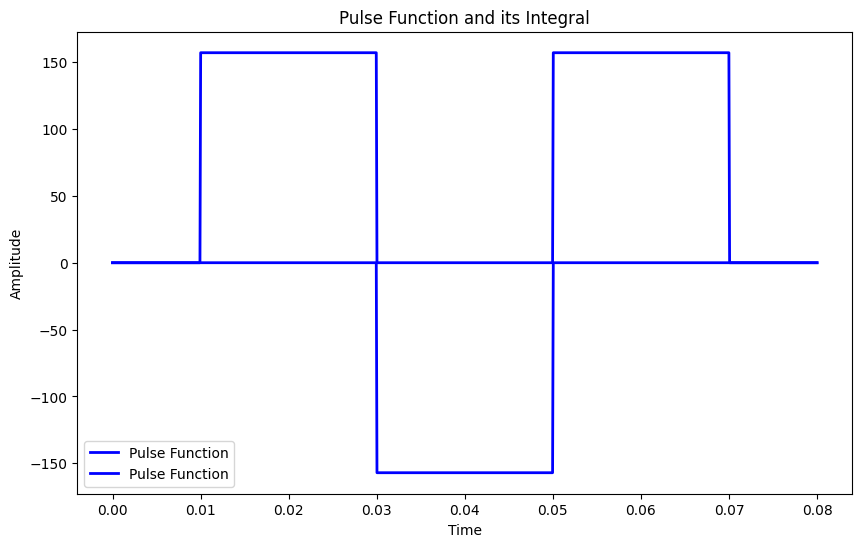

In [68]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t) for t in t_plot]
pulse_valuesp2 = [Omega_p2(t) for t in t_plot]

plt.figure(figsize=(10, 6))
plt.plot(t_plot, pulse_valuesp, 'b-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesp2, 'b-', linewidth=2, label='Pulse Function')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()

In [69]:
L_c = np.sqrt(gamma_c) * (gc * rc_dag)
L_R = np.sqrt(gamma_R) * (gt * rt_dag)
L_t = np.sqrt(gamma_R) * (et * rt_dag)

In [70]:
def Hnhermitian(t):
    h1 = tensor(hc, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), ht(t)) + tensor(Qobj(np.eye(2)), ht2(t))
    h2 = V_dd * tensor(hrr, hRR)
    h31 = -1j/2 * (L_c.dag() * L_c)
    h32 = -1j/2 * 1/2 * (L_R.dag() * L_R + L_t.dag() * L_t)
    h3 = tensor(h31, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), h32)
    return h1 + h2 + h3

In [71]:
Hnhermitian(0.01)

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j         78.53981634+0.j
   0.        +0.j          0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j         78.53981634+0.j          0.        -0.0009901j
   0.        +0.j          0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        -0.00091241j  0.        +0.j          0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j          0.        -0.00091241j 78.53981634+0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.j
   0.        +0.j         78.53981634+0.j          0.        -0.00190251j]]

In [72]:
c_ops = tensor(L_c, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), L_R)

In [73]:
c_ops

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.         0.         0.04449942 0.04271788 0.         0.        ]
 [0.         0.         0.         0.         0.04271788 0.        ]
 [0.         0.         0.         0.         0.         0.04271788]
 [0.         0.         0.         0.         0.         0.04449942]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]]

In [74]:
psi00 = tensor(gc,gt)
psi_0 = tensor(gc,gt)
psi_1 = tensor(gc,et)
psi_r = tensor(gc,rt)


In [75]:
mc = mcsolve(Hnhermitian, psi00, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_r*psi_r.dag()])

10.0%. Run time:  11.73s. Est. time left: 00:00:01:45
20.0%. Run time:  24.02s. Est. time left: 00:00:01:36
30.0%. Run time:  36.08s. Est. time left: 00:00:01:24
40.0%. Run time:  48.21s. Est. time left: 00:00:01:12
50.0%. Run time:  60.49s. Est. time left: 00:00:01:00
60.0%. Run time:  72.80s. Est. time left: 00:00:00:48
70.0%. Run time:  84.98s. Est. time left: 00:00:00:36
80.0%. Run time:  97.40s. Est. time left: 00:00:00:24
90.0%. Run time: 109.57s. Est. time left: 00:00:00:12
100.0%. Run time: 121.57s. Est. time left: 00:00:00:00
Total run time: 121.83s


In [76]:
print(mc.expect[1][999])


1.5286321962099929e-10


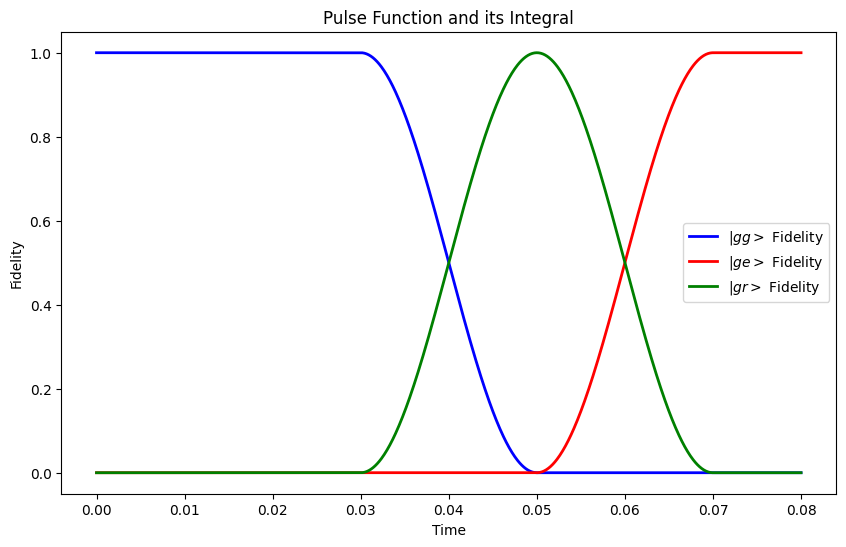

In [77]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc.expect[0],'-b',lw=2,label='$|gg>$ Fidelity')

plt.plot(tlist,mc.expect[1],'-r',lw=2,label='$|ge>$ Fidelity')

plt.plot(tlist,mc.expect[2],'-g',lw=2,label='$|gr>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()